In [54]:
import pandas as pd
from sklearn.datasets import load_digits
digits = load_digits()

LOAD_DIGITS IS A INBUILT DATASET WHICH WE CAN USE IT PRACTICE,, 

   DIGITS = LOAD_DIGITS() MEANS WE ARE LOADING THE DATASET INTO DIGITS

In [55]:
dir(digits)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

In [56]:
import matplotlib.pyplot as plt

In [57]:
for i in range(5):
    print(digits.target[i])

0
1
2
3
4


The dataset contains images of handwritten digits (0–9) in 8×8 pixel resolution. 

Each row = one digit image (8×8 = 64 pixels).

original 2D images. digits.images → original 2D images.

Shape: (1797, 8, 8)

In [58]:
digits.images[0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

plt.gray() → sets grayscale colormap.

digits.images[i] → fetches an 8×8 digit image.

plt.matshow() → displays the pixel grid as an image.

<Figure size 640x480 with 0 Axes>

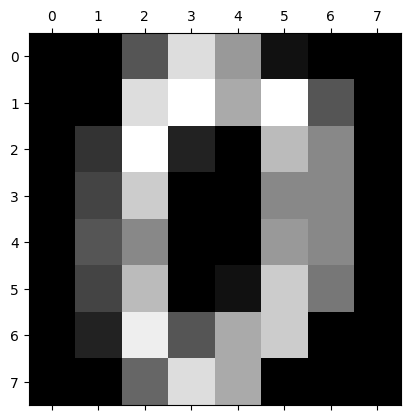

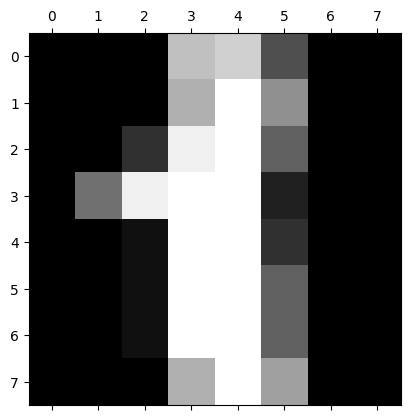

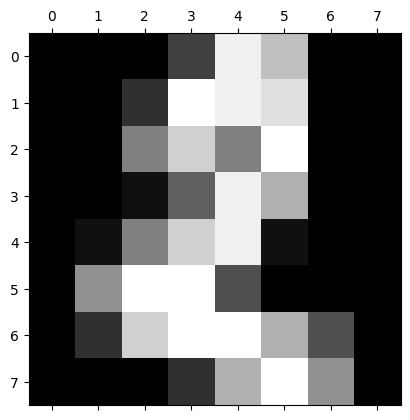

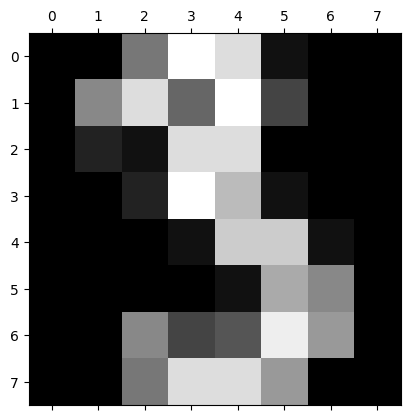

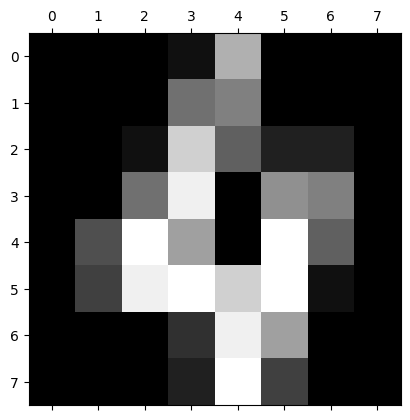

In [59]:
%matplotlib inline
plt.gray()
for i in range(5):
    plt.matshow(digits.images[i])

In [60]:
dir(digits)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

In [61]:
digits.data[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

In [62]:
digits.feature_names[0]

'pixel_0_0'

In [63]:
digits.target_names[0]

0

In [64]:
df = pd.DataFrame(digits.data)

In [65]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


64 columns = 64 pixels

each row has 1 image

now we need to separete input and output(target)

In [66]:
dir(digits)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

In [72]:
df["target"] = digits.target

In [73]:
input = df.drop("target",axis=1)
target = df.target


In [74]:
from sklearn.model_selection import train_test_split

In [75]:
x_train,x_test,y_train,y_test= train_test_split(input,target,train_size=0.8)

In [76]:
from sklearn.ensemble import RandomForestClassifier

In [77]:
model = RandomForestClassifier(n_estimators=60)

n_estimators is a hyper perameter we can change as our wish, that many number of decision trees it will creat to perform the model from our data we need to take the best accurace with less number of trees

In [78]:
model.fit(x_train,y_train)

RandomForestClassifier(n_estimators=60)

In [79]:
model.score(x_test,y_test)

0.9722222222222222

In [80]:
y_pred = model.predict(x_test)

In [81]:
len(y_pred)

360

To know where our model making mistake we use CONFUSION MATRIX
it is common for all the ML models

                                                CONFUSION MATRIX

In [82]:
from sklearn.metrics import confusion_matrix

In [83]:
cm = confusion_matrix(y_test,y_pred)

y_test is the actual output

y_pred is the predicted output

In [84]:
cm

array([[34,  0,  0,  0,  1,  0,  0,  0,  0,  0],
       [ 0, 37,  0,  0,  0,  1,  0,  0,  0,  0],
       [ 0,  0, 33,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 37,  0,  1,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 32,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  1,  0, 34,  0,  0,  0,  3],
       [ 0,  1,  0,  0,  0,  0, 38,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 38,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 29,  0],
       [ 0,  0,  0,  1,  0,  0,  0,  1,  0, 38]])

here we installed seaborn for better visualization

plt.figure()

Creates a new blank figure to draw the plot on.

sn.heatmap(cm, annot=True)

Draws a heatmap of the confusion matrix cm.

cm should be a 2D array (like output from confusion_matrix(y_true, y_pred)).

annot=True → shows the numbers inside the cells.

Text(50.722222222222214, 0.5, 'actual')

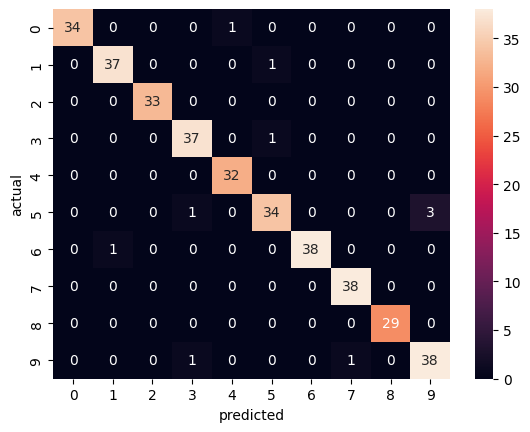

In [85]:
%matplotlib inline
import seaborn as sn
plt.figure()
sn.heatmap(cm,annot=True)
plt.xlabel("predicted")
plt.ylabel("actual")